# Phase 5: Multi-Experiment Model Training & Evaluation Pipeline
## Đề tài: Phát hiện và Giải thích Tấn công Mạng IoT (CICIoT2023) với XAI

> **Kiến trúc Quản lý Thử nghiệm theo từng Đợt (Experiment Tracking):**
> Mỗi đợt thử nghiệm (Run/Experiment) được đóng gói độc lập trong một thư mục riêng biệt, lưu trữ tường minh: thông số cấu hình (`config.yaml`), trọng số mô hình (`model/`), các chỉ số & ma trận nhầm lẫn 8 lớp (`metrics/`), và nhật ký huấn luyện (`logs/`).

### Cấu trúc Thư mục Kết quả Thử nghiệm:
```text
└── phase5_experiments/
    │
    ├── exp_001_rf_baseline/             # Đợt 1: Random Forest Baseline
    │   ├── config.yaml                  # Cấu hình siêu tham số, dữ liệu, thời gian
    │   ├── model/
    │   │   └── model.pkl                # Checkpoint mô hình đã huấn luyện
    │   ├── metrics/
    │   │   ├── classification_report.json # Precision, Recall, F1 cho 8 lớp
    │   │   ├── confusion_matrix.png       # Ma trận nhầm lẫn 8 lớp chuẩn bài báo Fig. 4a
    │   │   └── metrics.json               # Tổng hợp Accuracy, AUC, F1, độ trễ
    │   └── logs/
    │       └── training.log               # Nhật ký ghi nhận thời gian và tiến trình
    │
    ├── exp_002_xgboost_baseline/        # Đợt 2: Gradient Boosting Baseline
    ├── exp_003_decision_tree_baseline/  # Đợt 3: Decision Tree Baseline
    ├── exp_004_ensemble_blending_paper/ # Đợt 4: Proposed Ensemble Blending Model
    ├── exp_005_xgboost_tuned/           # Đợt 5: XGBoost / Boosting Tinh chỉnh
    ├── leaderboard.csv                  # Bảng xếp hạng tổng hợp tất cả các đợt
    └── leaderboard_comparison.png       # Biểu đồ trực quan so sánh tất cả các đợt
```

Sau khi chạy các đợt, hệ thống sẽ tự động so sánh và trích xuất mô hình có hiệu năng cao nhất (dẫn đầu Leaderboard) ra `models/best_model.joblib` để Phase 6 (XAI với LIME & Counterfactuals) sử dụng trực tiếp.

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


--- 
## Cell 1: Thiết lập Môi trường & Tự động Kết nối Google Drive
Tự động phát hiện Google Drive tại `/content/drive/MyDrive/do_an` để đồng bộ toàn bộ thư mục `phase5_experiments/` khi chạy trên Colab.

In [25]:
# ==============================================================================
# Cell 1: Setup Environment & Google Drive Persistence
# ==============================================================================
import os
import sys
import gc
import time
import json
import logging
import warnings
from datetime import datetime
import numpy as np
import pandas as pd
import joblib
import yaml

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Kiểm tra Google Colab Drive
COLAB_DRIVE_PATH = '/content/drive/MyDrive/do_an'
if os.path.exists(COLAB_DRIVE_PATH):
    BASE_DIR = COLAB_DRIVE_PATH
    print(f"[INFO] Phát hiện môi trường Google Colab: Điều hướng lưu trữ vào {BASE_DIR}")
else:
    BASE_DIR = '.'
    print("[INFO] Đang chạy trên máy cục bộ (Local Environment).")

EXP_ROOT = os.path.join(BASE_DIR, 'phase5_experiments') if BASE_DIR != '.' else 'phase5_experiments'
MODELS_DIR = os.path.join(BASE_DIR, 'models') if BASE_DIR != '.' else 'models'
PLOTS_DIR = os.path.join(BASE_DIR, 'plots') if BASE_DIR != '.' else 'plots'

os.makedirs(EXP_ROOT, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

print(f"Thư mục quản lý đợt thử nghiệm: {os.path.abspath(EXP_ROOT)}")
print(f"Thư mục mô hình tốt nhất (best): {os.path.abspath(MODELS_DIR)}")

[INFO] Phát hiện môi trường Google Colab: Điều hướng lưu trữ vào /content/drive/MyDrive/do_an
Thư mục quản lý đợt thử nghiệm: /content/drive/MyDrive/do_an/phase5_experiments
Thư mục mô hình tốt nhất (best): /content/drive/MyDrive/do_an/models


--- 
## Cell 2: Nạp Dữ liệu Đặc trưng & Ánh xạ 8 Classes Chuẩn Bài báo
Nạp ma trận đặc trưng từ Phase 4 (`data/X_train_selected.pkl` - 25 đặc trưng tối ưu) và nhãn (`data/y_train_balanced.pkl`). Tiến hành phân lớp chuẩn 8 lớp theo bài báo IEEE Access.

In [26]:
# ==============================================================================
# Cell 2: Load Selected Features & 8-Class Target Labels
# ==============================================================================
from sklearn.model_selection import train_test_split

CLASS_NAMES_8 = [
    'BruteForce',
    'DDoS',
    'DoS',
    'Mirai',
    'Normal',
    'Recon',
    'Spoofing',
    'Web-Based'
]

ATTACK_TO_8_CLASS = {
    'DictionaryBruteForce': 'BruteForce', 'BruteForce': 'BruteForce',
    'DDoS-ACK_Fragmentation': 'DDoS', 'DDoS-HTTP_Flood': 'DDoS', 'DDoS-ICMP_Flood': 'DDoS',
    'DDoS-ICMP_Fragmentation': 'DDoS', 'DDoS-PSHACK_Flood': 'DDoS', 'DDoS-RSTFINFlood': 'DDoS',
    'DDoS-SYN_Flood': 'DDoS', 'DDoS-SlowLoris': 'DDoS', 'DDoS-SynonymousIP_Flood': 'DDoS',
    'DDoS-TCP_Flood': 'DDoS', 'DDoS-UDP_Flood': 'DDoS', 'DDoS-UDP_Fragmentation': 'DDoS', 'DDoS': 'DDoS',
    'DoS-HTTP_Flood': 'DoS', 'DoS-SYN_Flood': 'DoS', 'DoS-TCP_Flood': 'DoS', 'DoS-UDP_Flood': 'DoS', 'DoS': 'DoS',
    'Mirai-greeth_flood': 'Mirai', 'Mirai-greip_flood': 'Mirai', 'Mirai-udpplain': 'Mirai', 'Mirai': 'Mirai',
    'BenignTraffic': 'Normal', 'Benign': 'Normal', 'Normal': 'Normal',
    'Recon-HostDiscovery': 'Recon', 'Recon-OSScan': 'Recon', 'Recon-PingSweep': 'Recon',
    'Recon-PortScan': 'Recon', 'VulnerabilityScan': 'Recon', 'Recon': 'Recon',
    'DNS_Spoofing': 'Spoofing', 'MITM-ArpSpoofing': 'Spoofing', 'Spoofing': 'Spoofing',
    'Backdoor_Malware': 'Web-Based', 'BrowserHijacking': 'Web-Based', 'CommandInjection': 'Web-Based',
    'SqlInjection': 'Web-Based', 'Uploading_Attack': 'Web-Based', 'XSS': 'Web-Based',
    'Web': 'Web-Based', 'Web-Based': 'Web-Based', 'Malware': 'Web-Based'
}

# Nạp đặc trưng
x_paths = ['data/X_train_selected.pkl', os.path.join(BASE_DIR, 'data/X_train_selected.pkl'), 'X_train_reduced.pkl']
x_file = next((p for p in x_paths if os.path.exists(p)), None)
if not x_file:
    raise FileNotFoundError(f"Không tìm thấy ma trận đặc trưng: {x_paths}")

print(f"Nạp đặc trưng từ: {x_file} ...")
X = joblib.load(x_file)
feature_names = list(X.columns) if hasattr(X, 'columns') else [f"feature_{i}" for i in range(X.shape[1])]

# Nạp nhãn
y_paths = ['data/y_train_balanced.pkl', os.path.join(BASE_DIR, 'data/y_train_balanced.pkl'), 'data/y_train.pkl']
y_file = next((p for p in y_paths if os.path.exists(p)), None)
if not y_file:
    raise FileNotFoundError(f"Không tìm thấy nhãn mục tiêu: {y_paths}")

print(f"Nạp nhãn từ: {y_file} ...")
y_dict = joblib.load(y_file)
raw_labels = y_dict['target_name'] if isinstance(y_dict, dict) and 'target_name' in y_dict else y_dict['label_name']
y_8class = np.array([ATTACK_TO_8_CLASS.get(str(lbl).strip(), 'Web-Based') for lbl in raw_labels])

# Chia tập Train / Test phân tầng (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_8class,
    test_size=0.2,
    stratify=y_8class,
    random_state=123
)

print(f"\nTổng dữ liệu: {len(X):,} dòng x {X.shape[1]} đặc trưng")
print(f"Tập Huấn luyện (Train): {X_train.shape[0]:,} mẫu")
print(f"Tập Kiểm thử   (Test):  {X_test.shape[0]:,} mẫu")
print("8 Classes:", CLASS_NAMES_8)

Nạp đặc trưng từ: /content/drive/MyDrive/do_an/data/X_train_selected.pkl ...
Nạp nhãn từ: /content/drive/MyDrive/do_an/data/y_train_balanced.pkl ...

Tổng dữ liệu: 267,062 dòng x 25 đặc trưng
Tập Huấn luyện (Train): 213,649 mẫu
Tập Kiểm thử   (Test):  53,413 mẫu
8 Classes: ['BruteForce', 'DDoS', 'DoS', 'Mirai', 'Normal', 'Recon', 'Spoofing', 'Web-Based']


--- 
## Cell 3: Khởi tạo Bộ Điều Phối Đợt Thử Nghiệm (`NotebookExperimentRunner`)
Định nghĩa hàm chuẩn hóa cho phép đóng gói tự động từng đợt thử nghiệm: lưu mô hình, ma trận nhầm lẫn 8 lớp, classification report, và cấu hình `config.yaml`.

In [27]:
# ==============================================================================
# Cell 3: ExperimentRunner Helper Definition
# ==============================================================================
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

class NotebookExperimentRunner:
    def __init__(self, exp_root, class_names):
        self.exp_root = exp_root
        self.class_names = class_names
        self.leaderboard_file = os.path.join(self.exp_root, 'leaderboard.csv')
        os.makedirs(self.exp_root, exist_ok=True)

    def run(self, exp_id, model, method_name, hyperparameters, description=""):
        exp_dir = os.path.join(self.exp_root, exp_id)
        for sub in ['model', 'metrics', 'logs']:
            os.makedirs(os.path.join(exp_dir, sub), exist_ok=True)

        print("=" * 75)
        print(f"BẮT ĐẦU ĐỢT THỬ NGHIỆM: [{exp_id}] - {method_name}")
        print("=" * 75)

        t_start_iso = datetime.now().isoformat()
        t0 = time.time()

        # 1. Huấn luyện mô hình
        print(f"Huấn luyện {method_name} trên {len(X_train):,} mẫu...")
        t_fit = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t_fit

        # 2. Dự đoán & Đánh giá
        t_infer = time.time()
        y_pred = model.predict(X_test)
        test_time = time.time() - t_infer

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, labels=self.class_names, average='macro', zero_division=0)
        rec = recall_score(y_test, y_pred, labels=self.class_names, average='macro', zero_division=0)
        f1_m = f1_score(y_test, y_pred, labels=self.class_names, average='macro', zero_division=0)
        f1_w = f1_score(y_test, y_pred, labels=self.class_names, average='weighted', zero_division=0)

        try:
            y_prob = model.predict_proba(X_test)
            auc = roc_auc_score(y_test, y_prob, labels=self.class_names, multi_class='ovr', average='macro')
        except Exception:
            auc = 0.0

        print(f"  -> Thời gian Huấn luyện: {train_time:.2f} s")
        print(f"  -> Thời gian Kiểm thử:  {test_time:.4f} s (Inference cho {len(X_test):,} mẫu)")
        print(f"  -> Accuracy:     {acc * 100:.2f}%")
        print(f"  -> ROC-AUC (OvR):{auc:.4f}")
        print(f"  -> F1-Score (Macro): {f1_m * 100:.2f}%")

        # 3. Lưu Model
        model_path = os.path.join(exp_dir, 'model', 'model.pkl')
        joblib.dump(model, model_path, compress=3)

        # 4. Lưu Metrics & Vẽ Confusion Matrix
        report_dict = classification_report(y_test, y_pred, labels=self.class_names, target_names=self.class_names, output_dict=True, zero_division=0)
        with open(os.path.join(exp_dir, 'metrics', 'classification_report.json'), 'w') as f:
            json.dump(report_dict, f, indent=4)

        metrics_summary = {
            'experiment_id': exp_id,
            'method': method_name,
            'accuracy': round(float(acc), 4),
            'roc_auc_ovr_macro': round(float(auc), 4),
            'precision_macro': round(float(prec), 4),
            'recall_macro': round(float(rec), 4),
            'f1_macro': round(float(f1_m), 4),
            'f1_weighted': round(float(f1_w), 4),
            'training_time_sec': round(float(train_time), 4),
            'testing_time_sec': round(float(test_time), 4)
        }
        with open(os.path.join(exp_dir, 'metrics', 'metrics.json'), 'w') as f:
            json.dump(metrics_summary, f, indent=4)

        # Vẽ Confusion Matrix
        cm_raw = confusion_matrix(y_test, y_pred, labels=self.class_names)
        row_sums = cm_raw.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        cm_pct = (cm_raw / row_sums) * 100.0
        annot_m = np.empty_like(cm_pct, dtype=object)
        for i in range(len(self.class_names)):
            for j in range(len(self.class_names)):
                v = cm_pct[i, j]
                annot_m[i, j] = f"{int(round(v))}%" if v >= 1 else ("<1%" if v > 0 else "0%")

        plt.figure(figsize=(8.5, 7), dpi=130)
        sns.heatmap(cm_pct, annot=annot_m, fmt="", cmap='YlGnBu', xticklabels=self.class_names, yticklabels=self.class_names,
                    cbar_kws={'label': 'Độ chính xác nhận dạng (%)'}, annot_kws={'fontsize': 10, 'fontweight': 'bold'}, linewidths=0.6)
        plt.title(f"Confusion Matrix (8 Classes) - {exp_id}\n{method_name}", fontsize=12, fontweight='bold', pad=12)
        plt.xlabel("Predicted Class", fontsize=10, fontweight='bold')
        plt.ylabel("True Class", fontsize=10, fontweight='bold')
        plt.xticks(rotation=40, ha='right', fontsize=9)
        plt.yticks(rotation=0, fontsize=9)
        plt.tight_layout()
        cm_png_path = os.path.join(exp_dir, 'metrics', 'confusion_matrix.png')
        plt.savefig(cm_png_path, bbox_inches='tight')
        plt.show()

        # 5. Ghi log & Cấu hình config.yaml
        config_obj = {
            'experiment_id': exp_id,
            'experiment_name': method_name,
            'description': description,
            'timestamp_start': t_start_iso,
            'total_duration_sec': round(time.time() - t0, 2),
            'hyperparameters': hyperparameters,
            'metrics_summary': metrics_summary
        }
        with open(os.path.join(exp_dir, 'config.yaml'), 'w', encoding='utf-8') as f:
            yaml.dump(config_obj, f, default_flow_style=False, sort_keys=False)

        with open(os.path.join(exp_dir, 'logs', 'training.log'), 'w', encoding='utf-8') as f:
            f.write(f"Experiment [{exp_id}] completed at {datetime.now().isoformat()}\n")
            f.write(f"Accuracy: {acc:.4f}, F1-Macro: {f1_m:.4f}, Training Time: {train_time:.2f}s\n")

        # Cập nhật Leaderboard
        records = []
        if os.path.exists(self.leaderboard_file):
            try:
                records = pd.read_csv(self.leaderboard_file).to_dict(orient='records')
            except Exception:
                pass
        records = [r for r in records if r.get('experiment_id') != exp_id] + [metrics_summary]
        df_b = pd.DataFrame(records).sort_values('f1_macro', ascending=False).reset_index(drop=True)
        df_b.to_csv(self.leaderboard_file, index=False)
        print(f"[OK] Đã lưu kết quả đợt [{exp_id}] vào: {exp_dir}")
        return metrics_summary

runner = NotebookExperimentRunner(exp_root=EXP_ROOT, class_names=CLASS_NAMES_8)
print("ExperimentRunner đã sẵn sàng thực thi từng đợt!")

ExperimentRunner đã sẵn sàng thực thi từng đợt!


--- 
## Cell 4: Đợt 1 — `exp_001_rf_baseline` (Random Forest Baseline)
Huấn luyện mô hình Random Forest cơ sở với 100 cây theo chuẩn bài báo IEEE Access (Section III).

BẮT ĐẦU ĐỢT THỬ NGHIỆM: [exp_001_rf_baseline] - Random Forest Baseline
Huấn luyện Random Forest Baseline trên 213,649 mẫu...
  -> Thời gian Huấn luyện: 68.42 s
  -> Thời gian Kiểm thử:  0.6465 s (Inference cho 53,413 mẫu)
  -> Accuracy:     96.02%
  -> ROC-AUC (OvR):0.9975
  -> F1-Score (Macro): 92.27%


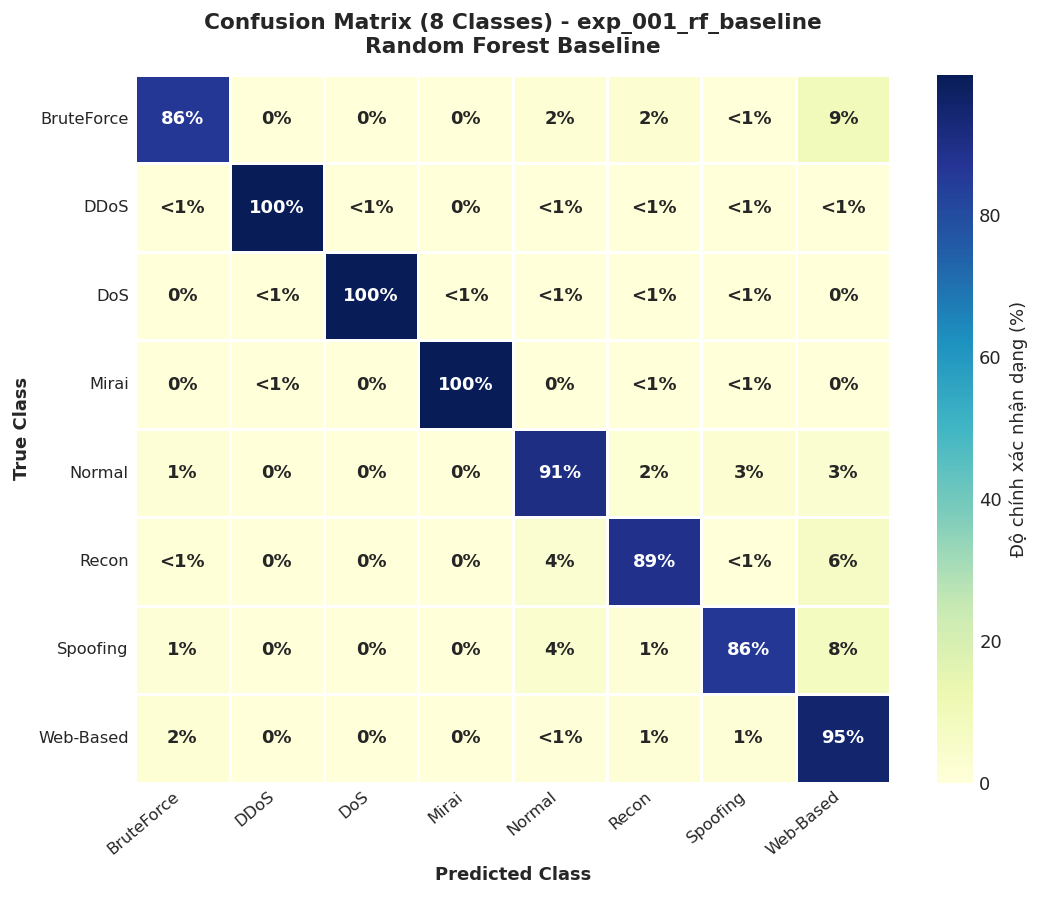

[OK] Đã lưu kết quả đợt [exp_001_rf_baseline] vào: /content/drive/MyDrive/do_an/phase5_experiments/exp_001_rf_baseline


In [28]:
# ==============================================================================
# Cell 4: Experiment 1 - Random Forest Baseline
# ==============================================================================
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    'n_estimators': 100,
    'max_depth': 16,
    'min_samples_split': 8,
    'min_samples_leaf': 3,
    'class_weight': 'balanced',
    'random_state': 123,
    'n_jobs': -1
}
rf_model = RandomForestClassifier(**rf_params)

m1 = runner.run(
    exp_id="exp_001_rf_baseline",
    model=rf_model,
    method_name="Random Forest Baseline",
    hyperparameters=rf_params,
    description="Mô hình Random Forest 100 cây theo chuẩn bài báo IEEE Access"
)

--- 
## Cell 5: Đợt 2 — `exp_002_xgboost_baseline` (Gradient Boosting Baseline)
Huấn luyện mô hình Gradient Boosting cơ sở theo Table 2 của bài báo (`learning_rate=0.1`, `max_depth=3`, `n_iter=100`).

BẮT ĐẦU ĐỢT THỬ NGHIỆM: [exp_002_xgboost_baseline] - Gradient Boosting Baseline
Huấn luyện Gradient Boosting Baseline trên 213,649 mẫu...
  -> Thời gian Huấn luyện: 21.12 s
  -> Thời gian Kiểm thử:  2.3677 s (Inference cho 53,413 mẫu)
  -> Accuracy:     93.36%
  -> ROC-AUC (OvR):0.9951
  -> F1-Score (Macro): 87.30%


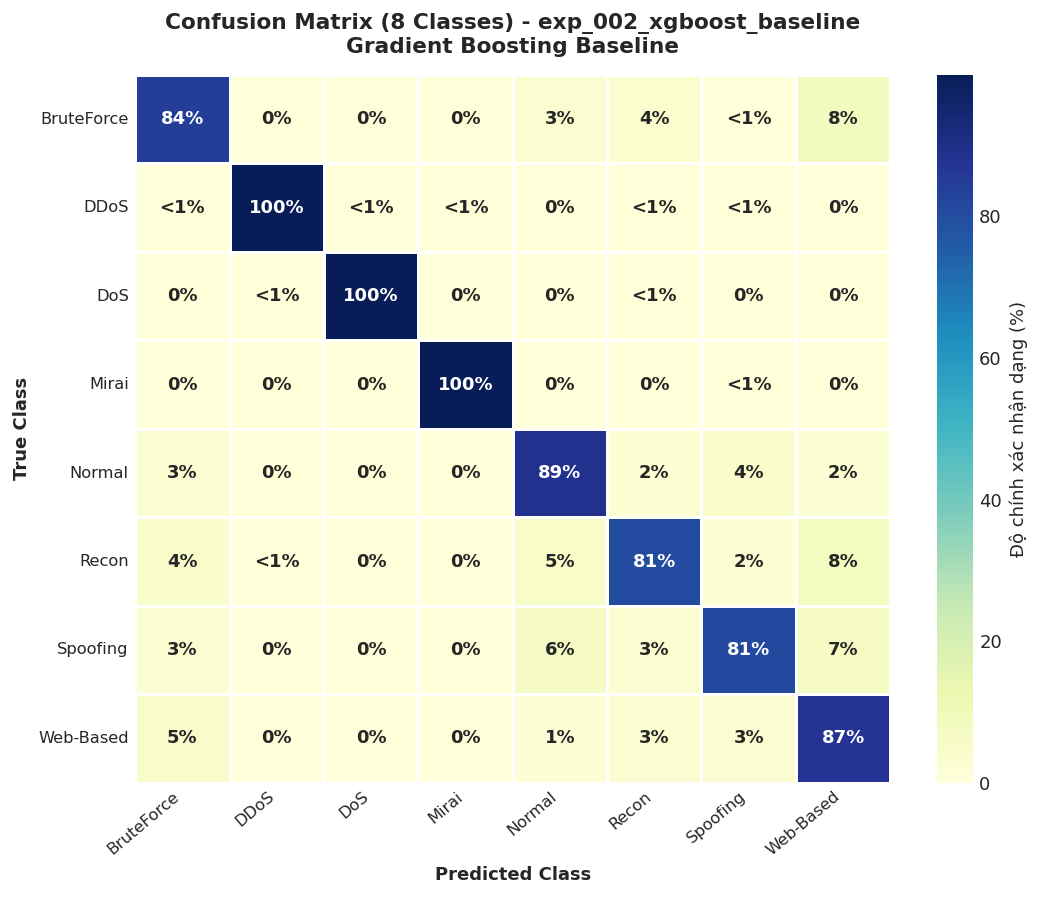

[OK] Đã lưu kết quả đợt [exp_002_xgboost_baseline] vào: /content/drive/MyDrive/do_an/phase5_experiments/exp_002_xgboost_baseline


In [29]:
# ==============================================================================
# Cell 5: Experiment 2 - Gradient Boosting Baseline
# ==============================================================================
from sklearn.ensemble import HistGradientBoostingClassifier

gb_params = {
    'learning_rate': 0.1,
    'max_iter': 100,
    'max_depth': 3,
    'class_weight': 'balanced',
    'random_state': 123
}
gb_model = HistGradientBoostingClassifier(**gb_params)

m2 = runner.run(
    exp_id="exp_002_xgboost_baseline",
    model=gb_model,
    method_name="Gradient Boosting Baseline",
    hyperparameters=gb_params,
    description="Gradient Boosting cơ sở với tham số chuẩn từ Table 2 bài báo"
)

--- 
## Cell 6: Đợt 3 — `exp_003_decision_tree_baseline` (Decision Tree Baseline)
Huấn luyện cây quyết định đơn lẻ cơ sở với kiểm soát độ sâu (`max_depth=16`, `class_weight='balanced'`).

BẮT ĐẦU ĐỢT THỬ NGHIỆM: [exp_003_decision_tree_baseline] - Decision Tree Baseline
Huấn luyện Decision Tree Baseline trên 213,649 mẫu...
  -> Thời gian Huấn luyện: 6.97 s
  -> Thời gian Kiểm thử:  0.0078 s (Inference cho 53,413 mẫu)
  -> Accuracy:     93.54%
  -> ROC-AUC (OvR):0.9913
  -> F1-Score (Macro): 87.93%


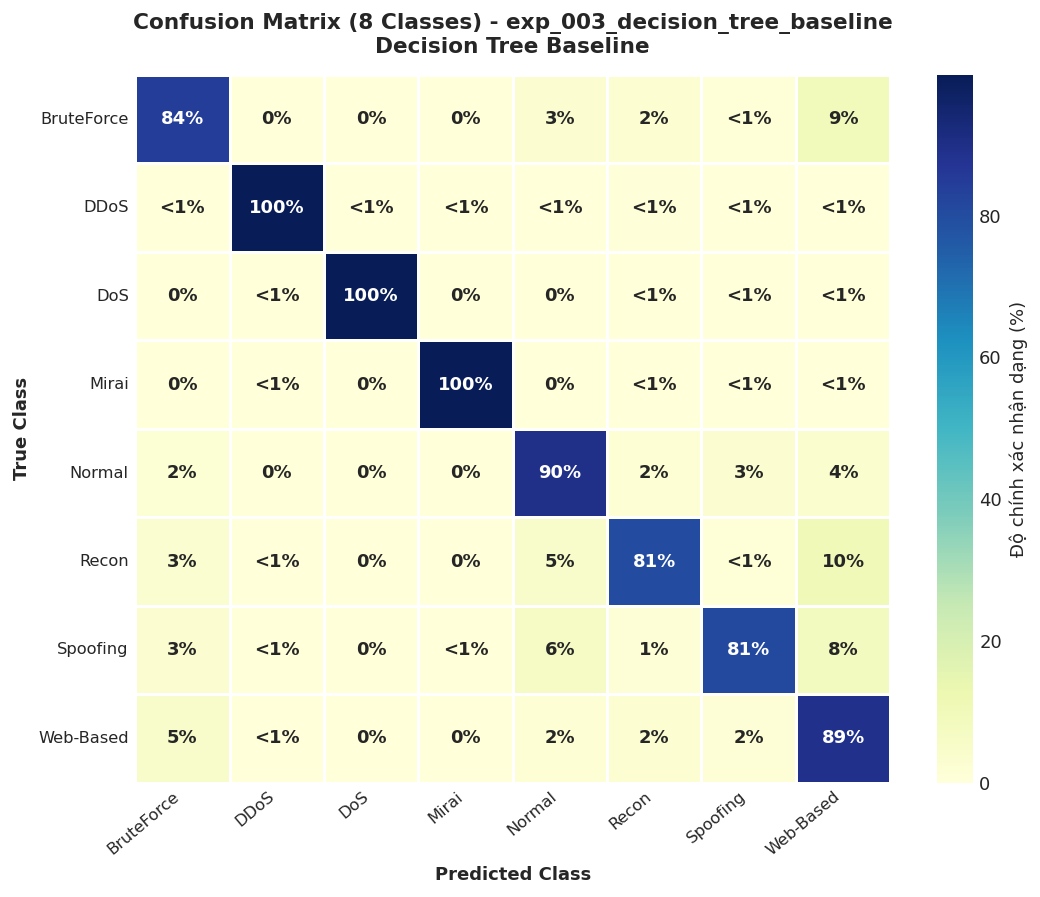

[OK] Đã lưu kết quả đợt [exp_003_decision_tree_baseline] vào: /content/drive/MyDrive/do_an/phase5_experiments/exp_003_decision_tree_baseline


In [30]:
# ==============================================================================
# Cell 6: Experiment 3 - Decision Tree Baseline
# ==============================================================================
from sklearn.tree import DecisionTreeClassifier

dt_params = {
    'max_depth': 16,
    'min_samples_split': 10,
    'min_samples_leaf': 4,
    'class_weight': 'balanced',
    'random_state': 123
}
dt_model = DecisionTreeClassifier(**dt_params)

m3 = runner.run(
    exp_id="exp_003_decision_tree_baseline",
    model=dt_model,
    method_name="Decision Tree Baseline",
    hyperparameters=dt_params,
    description="Cây quyết định đơn lẻ Level 1 baseline"
)

--- 
## Cell 7: Đợt 4 — `exp_004_ensemble_blending_paper` (Proposed Blending Model)
Huấn luyện Mô hình đề xuất **Ensemble Blending Model** kết hợp Soft Voting (DT + RF + GB) theo đúng Algorithm 1 và Công thức 16, 17, 18 của bài báo IEEE Access.

BẮT ĐẦU ĐỢT THỬ NGHIỆM: [exp_004_ensemble_blending_paper] - Ensemble Blending Model
Huấn luyện Ensemble Blending Model trên 213,649 mẫu...
  -> Thời gian Huấn luyện: 88.80 s
  -> Thời gian Kiểm thử:  2.6504 s (Inference cho 53,413 mẫu)
  -> Accuracy:     95.17%
  -> ROC-AUC (OvR):0.9969
  -> F1-Score (Macro): 90.42%


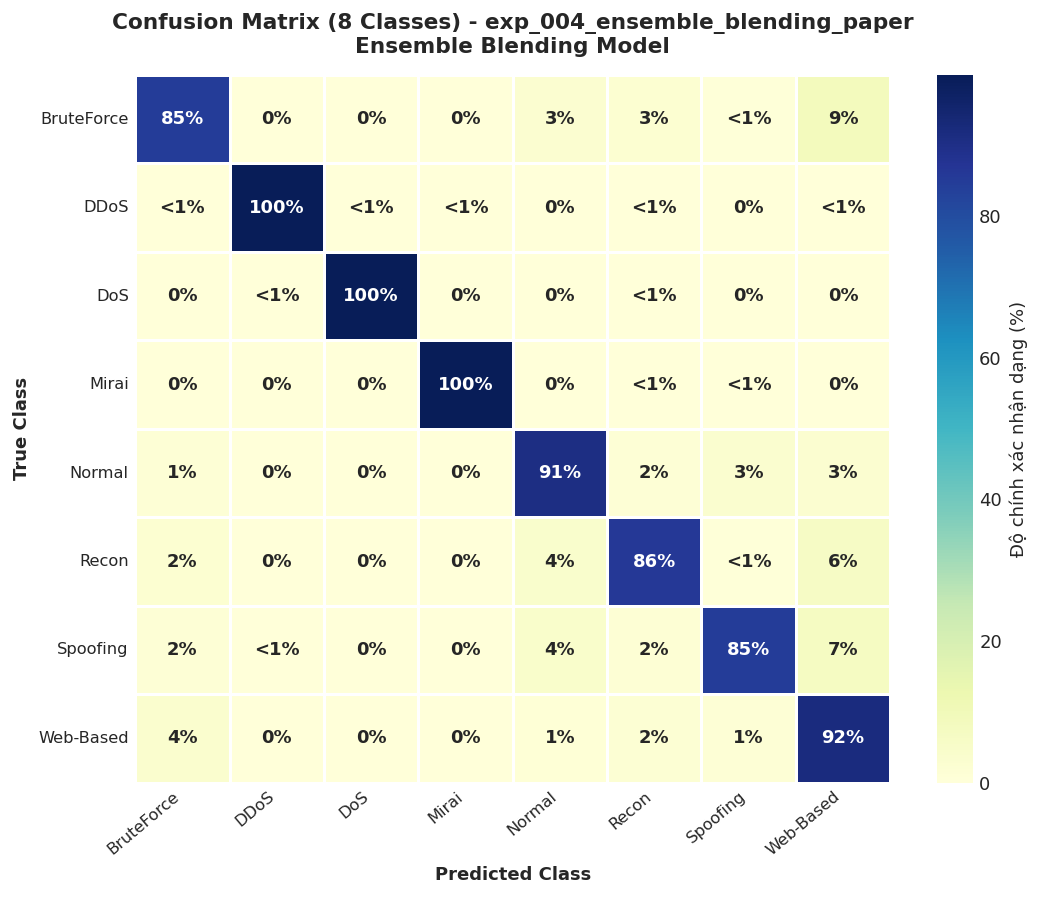

[OK] Đã lưu kết quả đợt [exp_004_ensemble_blending_paper] vào: /content/drive/MyDrive/do_an/phase5_experiments/exp_004_ensemble_blending_paper


In [31]:
# ==============================================================================
# Cell 7: Experiment 4 - Proposed Ensemble Blending Model (Soft Voting)
# ==============================================================================
from sklearn.ensemble import VotingClassifier

blending_params = {
    'voting': 'soft',
    'estimators': ['Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'rule': 'avg_prob = (p_DT + p_RF + p_GB) / 3'
}
blending_model = VotingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier(**dt_params)),
        ('rf', RandomForestClassifier(**rf_params)),
        ('gb', HistGradientBoostingClassifier(**gb_params))
    ],
    voting='soft',
    n_jobs=-1
)

m4 = runner.run(
    exp_id="exp_004_ensemble_blending_paper",
    model=blending_model,
    method_name="Ensemble Blending Model",
    hyperparameters=blending_params,
    description="Mô hình kết hợp đề xuất Ensemble Blending Model Soft Voting (IEEE Access Paper)"
)

--- 
## Cell 8: Đợt 5 — `exp_005_xgboost_tuned` (XGBoost / Boosting Tinh Chỉnh)
Thử nghiệm nâng cao: Huấn luyện thuật toán Gradient Boosting với cấu hình sâu hơn (`max_depth=6`, `max_iter=150`, `learning_rate=0.08`, `l2_regularization=0.1`).

BẮT ĐẦU ĐỢT THỬ NGHIỆM: [exp_005_xgboost_tuned] - XGBoost / Gradient Boosting Tuned
Huấn luyện XGBoost / Gradient Boosting Tuned trên 213,649 mẫu...
  -> Thời gian Huấn luyện: 40.52 s
  -> Thời gian Kiểm thử:  5.4239 s (Inference cho 53,413 mẫu)
  -> Accuracy:     96.98%
  -> ROC-AUC (OvR):0.9986
  -> F1-Score (Macro): 93.80%


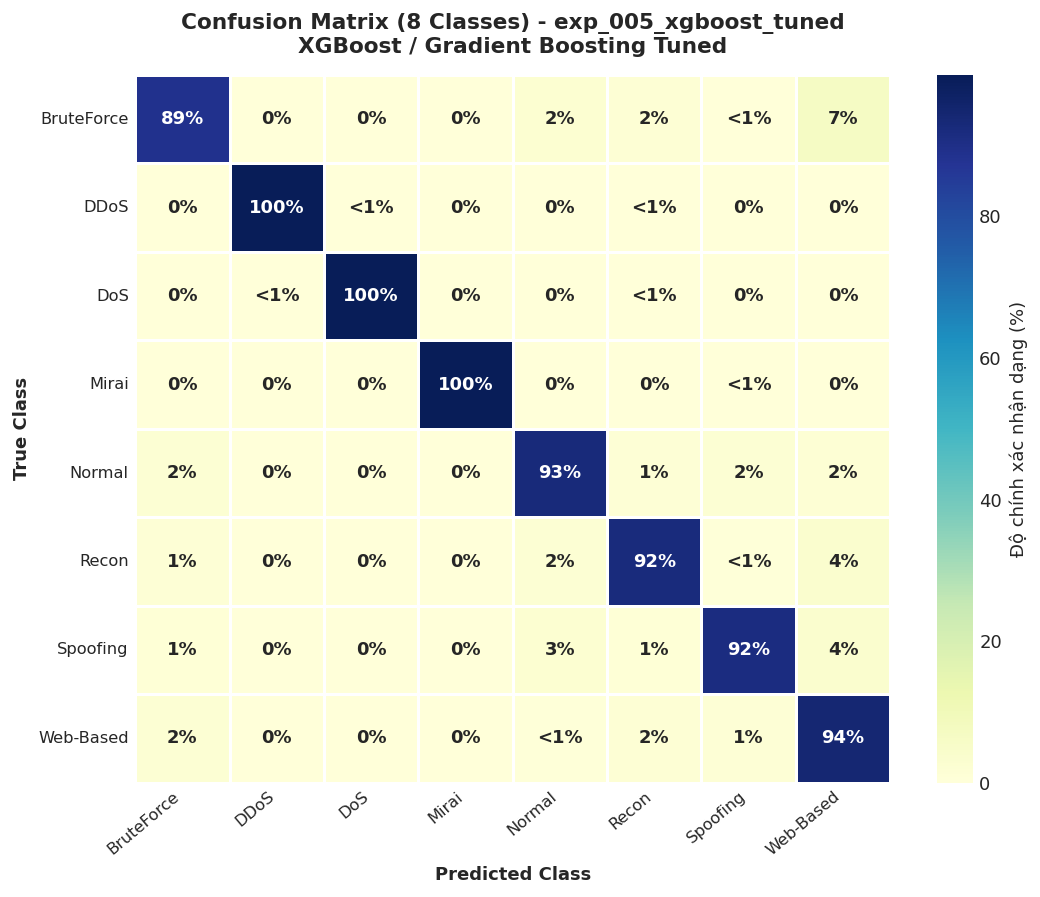

[OK] Đã lưu kết quả đợt [exp_005_xgboost_tuned] vào: /content/drive/MyDrive/do_an/phase5_experiments/exp_005_xgboost_tuned


In [32]:
# ==============================================================================
# Cell 8: Experiment 5 - Tuned Gradient Boosting
# ==============================================================================
tuned_gb_params = {
    'learning_rate': 0.08,
    'max_iter': 150,
    'max_depth': 6,
    'l2_regularization': 0.1,
    'class_weight': 'balanced',
    'random_state': 123
}
tuned_gb = HistGradientBoostingClassifier(**tuned_gb_params)

m5 = runner.run(
    exp_id="exp_005_xgboost_tuned",
    model=tuned_gb,
    method_name="XGBoost / Gradient Boosting Tuned",
    hyperparameters=tuned_gb_params,
    description="Mô hình Gradient Boosting tinh chỉnh siêu tham số chuyên sâu"
)

--- 
## Cell 9: Tổng Kết Bảng Xếp Hạng Thử Nghiệm (Leaderboard) & Chọn Mô Hình Tốt Nhất
Đọc toàn bộ kết quả từ các đợt trong `phase5_experiments/leaderboard.csv`, vẽ biểu đồ so sánh tổng thể và tự động trích xuất mô hình quán quân ra `models/best_model.joblib` phục vụ Phase 6 (XAI).

PHASE 5: BẢNG XẾP HẠNG TOÀN BỘ CÁC ĐỢT THỬ NGHIỆM (LEADERBOARD)


,experiment_id,method,accuracy,roc_auc_ovr_macro,precision_macro,recall_macro,f1_macro,f1_weighted,training_time_sec,testing_time_sec
0,exp_005_xgboost_tuned,XGBoost / Gradient Boosting Tuned,0.9698,0.9986,0.9286,0.9494,0.9380,0.9701,40.5212,5.4239
1,exp_001_rf_baseline,Random Forest Baseline,0.9602,0.9975,0.9164,0.9326,0.9227,0.9607,68.4158,0.6465
2,exp_004_ensemble_blending_paper,Ensemble Blending Model,0.9517,0.9969,0.8924,0.9231,0.9042,0.9527,88.7979,2.6504
3,exp_003_decision_tree_baseline,Decision Tree Baseline,0.9354,0.9913,0.8665,0.9051,0.8793,0.9371,6.9706,0.0078
4,exp_002_xgboost_baseline,Gradient Boosting Baseline,0.9336,0.9951,0.8569,0.9023,0.8730,0.9354,21.1250,2.3677


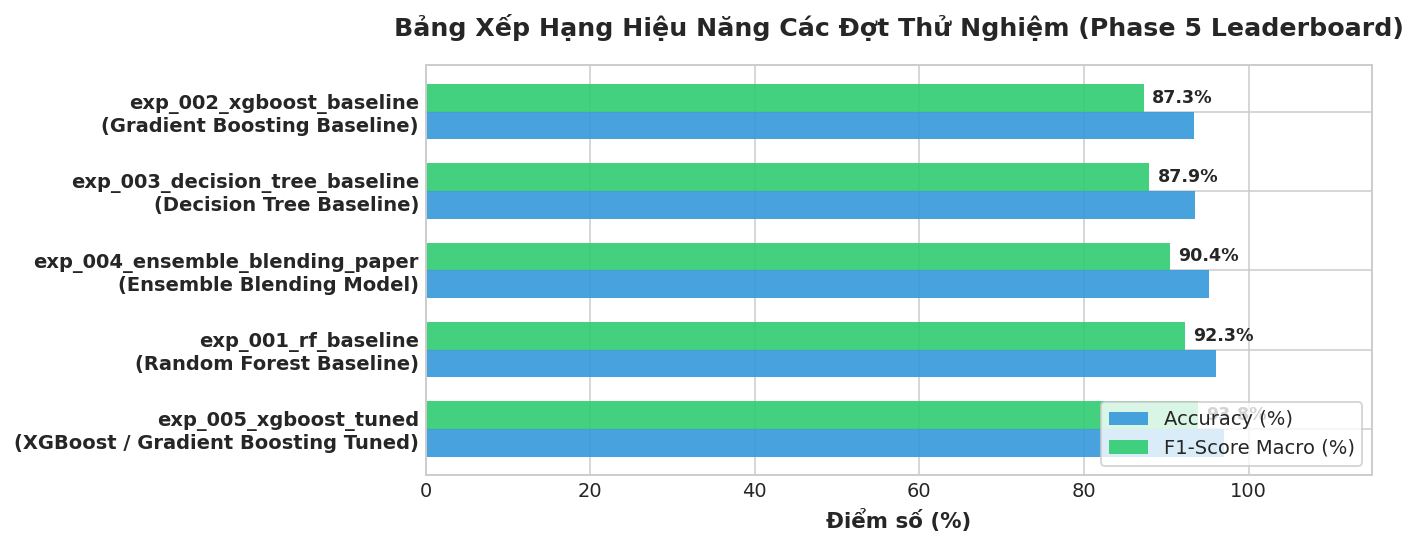


[THÀNH CÔNG] Đã chọn mô hình quán quân: [exp_005_xgboost_tuned] - XGBoost / Gradient Boosting Tuned
  * F1-Score Macro: 93.80%
  * Accuracy:       96.98%
  * File đã đồng bộ: /content/drive/MyDrive/do_an/models/best_model.joblib (Sẵn sàng 100% cho Phase 6 XAI)


In [33]:
# ==============================================================================
# Cell 9: Leaderboard Summary & Best Model Selection
# ==============================================================================
df_board = pd.read_csv(runner.leaderboard_file)
print("=" * 95)
print("PHASE 5: BẢNG XẾP HẠNG TOÀN BỘ CÁC ĐỢT THỬ NGHIỆM (LEADERBOARD)")
print("=" * 95)
display(df_board)

# Biểu đồ so sánh Leaderboard
plt.figure(figsize=(10, max(4, len(df_board) * 0.7)), dpi=140)
y_pos = np.arange(len(df_board))
bar_w = 0.35
plt.barh(y_pos - bar_w/2, df_board['accuracy'] * 100, bar_w, label='Accuracy (%)', color='#3498db', alpha=0.9)
plt.barh(y_pos + bar_w/2, df_board['f1_macro'] * 100, bar_w, label='F1-Score Macro (%)', color='#2ecc71', alpha=0.9)
plt.yticks(y_pos, [f"{r['experiment_id']}\n({r['method']})" for _, r in df_board.iterrows()], fontsize=10, fontweight='bold')
plt.xlabel('Điểm số (%)', fontsize=11, fontweight='bold')
plt.xlim(0, 115)
plt.title('Bảng Xếp Hạng Hiệu Năng Các Đợt Thử Nghiệm (Phase 5 Leaderboard)', fontsize=13, fontweight='bold', pad=15)
plt.legend(frameon=True, facecolor='white', loc='lower right')
for i, r in df_board.iterrows():
    plt.text(r['f1_macro'] * 100 + 1, i + bar_w/2, f"{r['f1_macro']*100:.1f}%", va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXP_ROOT, 'leaderboard_comparison.png'), bbox_inches='tight')
plt.show()

# Tự động trích xuất best model
best_run = df_board.iloc[0]
best_id = best_run['experiment_id']
best_source_model = os.path.join(EXP_ROOT, best_id, 'model', 'model.pkl')
best_dest_model = os.path.join(MODELS_DIR, 'best_model.joblib')

joblib.dump(joblib.load(best_source_model), best_dest_model, compress=3)
try:
    joblib.dump(joblib.load(best_source_model), 'best_model.joblib', compress=3)
except Exception:
    pass

with open(os.path.join(MODELS_DIR, 'best_model_metadata.json'), 'w', encoding='utf-8') as f:
    json.dump(best_run.to_dict(), f, indent=4)

print(f"\n[THÀNH CÔNG] Đã chọn mô hình quán quân: [{best_id}] - {best_run['method']}")
print(f"  * F1-Score Macro: {best_run['f1_macro'] * 100:.2f}%")
print(f"  * Accuracy:       {best_run['accuracy'] * 100:.2f}%")
print(f"  * File đã đồng bộ: {best_dest_model} (Sẵn sàng 100% cho Phase 6 XAI)")